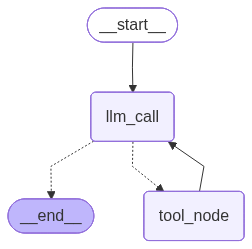

In [3]:
"""
"""


from typing import Literal
from langchain.tools import tool
from langchain_chroma import Chroma
from langchain_ollama import ChatOllama, OllamaEmbeddings
from typing_extensions import TypedDict, Annotated
from langchain.messages import SystemMessage, ToolMessage, AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
import operator
from IPython.display import Image, display


################################################################
"""
Initialize vector database and model
"""
################################################################

embeddings = OllamaEmbeddings(model="qwen3-embedding")
db = Chroma(
            persist_directory=str("student-counselor/chroma_db"),
            embedding_function=embeddings,
        )

model = ChatOllama(
    model="qwen3.6:35b", 
    temperature=0.5,
    num_predict=2048,
)


################################################################
"""
Create tools
"""
################################################################

@tool
def search_studiengang(query: str, k: int = 5) -> str:
    """
    Durchsucht die internen Informationskarten für Studiengängen nach Studiengangsinformationen, Inhalten, Zulassungsvoraussetzungen (NC) und weiteren studiengangsspezifischen Fragen.

    Args:
        query (str): Die Suchanfrage, die Informationen zu einem Studiengang oder studiengangsbezogenen Fragen enthält.
        k (int): Die Anzahl der zurückzugebenden relevanten Ergebnisse.
    
    Returns:
        str: Die relevantesten Informationen aus den Informationskarten, die der Anfrage entsprechen. Wenn keine relevanten Informationen gefunden werden, wird eine entsprechende Nachricht zurückgegeben.
    """
    matches = db.similarity_search(query, k=k)

    if not matches:
        return "Keine passenden Informationen gefunden."

    return "\n\n".join(
        [
            f"Treffer {index + 1}:\n"
            f"Studiengang: {match.metadata.get('Studiengang', 'unbekannt')}\n"
            f"Inhalt: {match.page_content}\n"
            f"Metadaten: {match.metadata}"
            for index, match in enumerate(matches)
        ]
    )


################################################################
"""
Create workflow
"""
################################################################

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int


# Augment the LLM with tools
tools = [search_studiengang]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)


system_prompt = """Du bist ein hochpräziser Assistent für die Studienberatung.
Nutze das Suchwerkzeug bei Fragen zu bestimmten Studiengängen, Bedingungen, oder Fragen, bei denen Informationen zu Studiengängen relevant sind. Du darfst kein eigenes Wissen verwenden, sondern nur das recherchierte Wissen anwenden.
Antworte auf Deutsch und in schönem Markdown-Format.
Auf Fragen, die nichts mit dem Studium zu tun haben, oder eine Meinung fordern, antworte mit 'Darüber habe ich leider keine Kenntnisse.'

Regeln:
    - Verwende das Suchwerkzeug, um Informationen zu Studiengängen zu finden
    - Antworte auf Deutsch und in schönem Markdown-Format
    - Entnehme dabei das Wissen aus der ANTWORT DES SEARCH-TOOLS
    - Gebe immer eine Antwort. Wenn du keine Informationen findest, teile dies in deiner Antwort mit.
    - Duze die Nutzer/in

Tools:
    - search_studiengang: Durchsucht die internen Informationskarten für Studiengängen nach Studiengangsinformationen, Inhalten, Zulassungsvoraussetzungen (NC) und weiteren studiengangsspezifischen Fragen
"""


# model node: decides whether to call the tool node
def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content=system_prompt
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls: # type: ignore
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


################################################################
"""
Build agent
"""
################################################################

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call) # type: ignore
agent_builder.add_node("tool_node", tool_node) # type: ignore

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))